<a href="https://colab.research.google.com/github/cheongmoi/nous-agent/blob/master/machine-learning/gradient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. 生成模拟数据
我们生成100套房屋的数据，面积范围90-150平米。为了使梯度下降更稳定，我们将面积单位转换为百平米，这样数据范围变为0.9-1.5。

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
n_samples = 100
areas_m2 = np.random.uniform(90, 150, n_samples)
areas = areas_m2 /100
prices = 250 * areas + 30 + np.random.normal(0, 1, n_samples) * 15

print(f"房屋数量：{len(areas)} 套")
print(f"面积范围：{areas_m2.min():.1f} - {areas_m2.max():.1f} 平米 ({areas.min():.2f} - {areas.max():.2f} 百平米)")
print(f"价格范围：{prices.min()} - {prices.max()} 万元")
print(f"真实规律：房价 = 2.5 × 面积（平米）+ 30")

房屋数量：100 套
面积范围：90.3 - 149.2 平米 (0.90 - 1.49 百平米)
价格范围：247.99272982307363 - 414.7603835667373 万元
真实规律：房价 = 2.5 × 面积（平米）+ 30


### 2. 梯度下降算法
梯度下降通过计算损失函数对参数的梯度，不断更新参数：

### 梯度下降公式推导

#### 1. 损失函数 (Loss Function)
我们使用均方误差 (MSE) 作为损失函数：
$$J(w, b) = \frac{1}{2m} \sum_{i=1}^{m} (y^{(i)} - \hat{y}^{(i)})^2 = \frac{1}{2m} \sum_{i=1}^{m} (y^{(i)} - (w x^{(i)} + b))^2$$

其中：
* $m$ 为样本数量 (`n_samples`)
* $y^{(i)}$ 为第 $i$ 个样本的真实价格 (`prices`)
* $\hat{y}^{(i)} = w x^{(i)} + b$ 为第 $i$ 个样本的预测价格

#### 2. 梯度计算 (Gradients)
损失函数对参数 $w$ 和 $b$ 的偏导数（梯度）为：
$$\frac{\partial J}{\partial w} = -\frac{1}{m} \sum_{i=1}^{m} (y^{(i)} - (w x^{(i)} + b)) \cdot x^{(i)}$$
$$\frac{\partial J}{\partial b} = -\frac{1}{m} \sum_{i=1}^{m} (y^{(i)} - (w x^{(i)} + b))$$

#### 3. 参数更新 (Parameter Updates)
沿着梯度的反方向更新参数（其中 $\alpha$ 为学习率 `learning_rate`）：
$$w \leftarrow w - \alpha \frac{\partial J}{\partial w}$$
$$b \leftarrow b - \alpha \frac{\partial J}{\partial b}$$

In [ ]:
def gradient_descent(X, y, lr=0.1, epochs=2000):
    """
    梯度下降算法实现 / Gradient Descent Implementation
    X: 输入特征 (面积/100) / Input features
    y: 标签 (房价) / Target labels
    lr: 学习率 / Learning rate
    epochs: 迭代次数 / Number of iterations
    """
    # 1. 初始化模型参数 w (权重) 和 b (偏置) 为 0.0
    w, b = 0.0, 0.0
    # n 为样本总数，用于后续计算平均梯度
    n = len(X)

    # 初始化 history 字典，用于记录训练过程中每一轮的参数值和损失值
    # 这有助于后续观察模型是否收敛以及绘制下降曲线
    history = {'w': [w], 'b': [b], 'loss': [np.mean((w * X + b - y) ** 2)]}

    # 开始循环迭代更新参数
    for epoch in range(epochs):
        # 步骤 1: 计算当前参数下的模型预测值 (y = w * x + b)
        y_pred = w * X + b

        # 步骤 2: 计算损失函数对 w 和 b 的偏导数 (梯度)
        # dw = (2/n) * Σ(预测值 - 真实值) * x
        # db = (2/n) * Σ(预测值 - 真实值)
        dw = (2/n) * np.sum((y_pred - y) * X)
        db = (2/n) * np.sum(y_pred - y)

        # 步骤 3: 沿着梯度的反方向更新参数 (w = w - 学习率 * 梯度)
        w -= lr * dw
        b -= lr * db

        # 计算更新参数后的均方误差 (MSE) 损失值
        current_loss = np.mean((y_pred - y) ** 2)

        # 将本轮迭代的结果存入 history
        history['w'].append(w)
        history['b'].append(b)
        history['loss'].append(current_loss)

        # 每隔 10% 的进度打印一次训练状态，方便查看进度
        if epoch % (epochs // 10) == 0:
            print(f"迭代 {epoch:5d}: w={w:.2f}, b={b:.2f}, loss={current_loss:.2f}")

    return history

# 运行梯度下降算法 / Run gradient descent
# 使用 5000 次迭代和 0.1 的学习率
history = gradient_descent(areas, prices, lr=0.1, epochs=5000)

# 打印最终回归方程
# 特别注意：因为训练时 area 缩小了 100 倍，所以最终输出 w 时需要除以 100 还原到“每平方米”的单价
final_w_per_sqm = history['w'][-1] / 100
final_b = history['b'][-1]
print(f"\n最终结果：房价 = {final_w_per_sqm:.3f} × 面积（平米）+ {final_b:.2f}")

迭代     0: w=78.46, b=65.10, loss=107933.06
迭代   500: w=217.85, b=68.31, loss=195.11
迭代  1000: w=232.92, b=50.26, loss=182.48
迭代  1500: w=236.99, b=45.38, loss=181.55
迭代  2000: w=238.10, b=44.06, loss=181.49
迭代  2500: w=238.40, b=43.70, loss=181.48
迭代  3000: w=238.48, b=43.61, loss=181.48
迭代  3500: w=238.50, b=43.58, loss=181.48
迭代  4000: w=238.50, b=43.57, loss=181.48
迭代  4500: w=238.51, b=43.57, loss=181.48

最终结果：房价 = 2.385 × 面积（平米）+ 43.57


## 3. 可视化结果
左图展示拟合效果，中图展示参数收敛过程，右图展示损失函数下降过程。

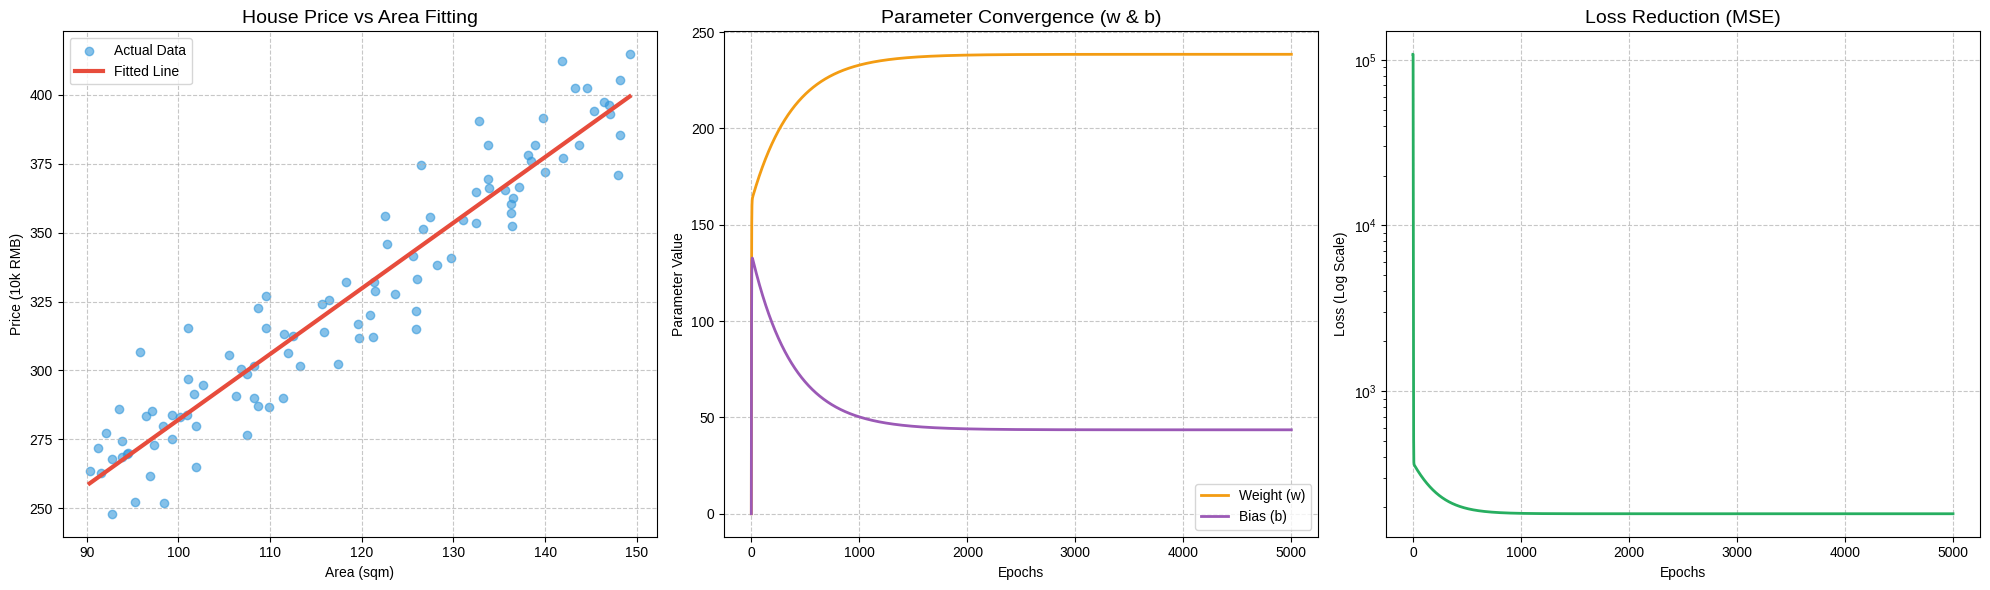

In [ ]:
import matplotlib.pyplot as plt

# 设置可视化图表样式（使用标准字体避免中文环境下的渲染报错）
plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号

# 创建一个 1行3列 的子图画布，尺寸设定为宽 20 英寸，高 6 英寸
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# ==========================================
# 1. 房屋面积与房价拟合效果图 (House Price vs Area Fitting)
# ==========================================
# 绘制原始数据的散点图。注意：输入特征 areas 曾被除以 100 缩放，这里乘回 100 还原为真实的平方米单位
ax1.scatter(areas * 100, prices, color='#3498db', alpha=0.6, label='Actual Data')

# 生成用于绘制拟合直线的等间距 x 值
x_plot = np.linspace(areas.min(), areas.max(), 100)
# 根据最后一轮迭代训练得到的 w 和 b 计算预测房价 y
y_plot = history['w'][-1] * x_plot + history['b'][-1]

# 绘制红色的最佳拟合直线
ax1.plot(x_plot * 100, y_plot, color='#e74c3c', linewidth=3, label='Fitted Line')
ax1.set_title('House Price vs Area Fitting', fontsize=14)  # 图表标题
ax1.set_xlabel('Area (sqm)')                             # x轴：面积（平方米）
ax1.set_ylabel('Price (10k RMB)')                         # y轴：价格（万元）
ax1.legend()                                              # 显示图例
ax1.grid(True, linestyle='--', alpha=0.7)                 # 开启网格线并设置半透明

# ==========================================
# 2. 参数 w 和 b 的收敛过程图 (Parameter Convergence Process)
# ==========================================
# 绘制整个训练迭代中权重参数 w 的变化曲线
ax2.plot(history['w'], label='Weight (w)', color='#f39c12', linewidth=2)
# 绘制整个训练迭代中偏置参数 b 的变化曲线
ax2.plot(history['b'], label='Bias (b)', color='#9b59b6', linewidth=2)
ax2.set_title('Parameter Convergence (w & b)', fontsize=14) # 图表标题
ax2.set_xlabel('Epochs')                                    # x轴：迭代轮数
ax2.set_ylabel('Parameter Value')                           # y轴：参数数值
ax2.legend()                                                # 显示图例
ax2.grid(True, linestyle='--', alpha=0.7)                  # 开启网格

# ==========================================
# 3. 损失值下降曲线图 (Loss Reduction Curve)
# ==========================================
# 绘制历史均方误差 (MSE) 损失值的下降过程
ax3.plot(history['loss'], color='#27ae60', linewidth=2)
# 使用对数坐标轴（Log Scale）显示 y 轴，因为前期 Loss 极大而后期极小，对数化更利于看清后期微小的收敛细节
ax3.set_yscale('log')
ax3.set_title('Loss Reduction (MSE)', fontsize=14)          # 图表标题
ax3.set_xlabel('Epochs')                                    # x轴：迭代轮数
ax3.set_ylabel('Loss (Log Scale)')                          # y轴：损失（对数刻度）
ax3.grid(True, linestyle='--', alpha=0.7)                  # 开启网格

# 自动调整子图间距，防止坐标标签重叠
plt.tight_layout()
plt.show()